In [1]:

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

In [2]:
load_dotenv()


True

In [3]:

class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [5]:

parent_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

subgraph_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.7
)

In [6]:

def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [7]:

subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [8]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [9]:

parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)


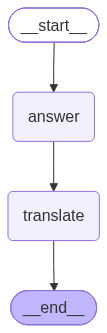

In [10]:

graph = parent_builder.compile()

graph

In [11]:
graph.invoke({'question': 'What is quantum physics'})


e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
e:\Chatbot-Langgraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'question': 'What is quantum physics',
 'answer_eng': [{'type': 'text',
   'text': '**Quantum physics** (also known as quantum mechanics) is the branch of science that studies the behavior of matter and energy at the most microscopic levels—specifically at the scale of atoms and subatomic particles (like electrons, protons, and photons).\n\nTo understand it, it helps to contrast it with **classical physics** (the physics of everyday life, like gravity, falling apples, and rolling balls). While classical physics predicts the predictable, orderly world we see around us, quantum physics reveals a bizarre, counterintuitive realm where the normal rules of reality do not apply.\n\nHere are the core concepts that define quantum physics:\n\n### 1. Quantization (Energy comes in "packets")\nIn our everyday world, things like light and heat seem to flow in a continuous stream. However, quantum physics discovered that at the atomic level, energy is emitted or absorbed in discrete, indivisible pac